In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\aishw\Downloads\project_electric vehicles.csv (1).xls")
df

,Unnamed: 0,company,Prices,models,Range,battery,singlecharge_km,fastcharge,Efficiency,weight
0,0,BMW,"€70,900",iX3,610 km,108.7 kWh,742 km,230 kW,178 Wh/km,"2,360 kg"
1,1,MG,"€39,990",MG4,360 km,61.7 kWh,401 km,107 kW,171 Wh/km,"1,726 kg"
2,2,Tesla,"€37,970",Model,445 km,60.0 kWh,523 km,110 kW,135 Wh/km,"1,847 kg"
3,3,BMW,"€77,300",iX,360 km,71.0 kWh,382 km,92 kW,197 Wh/km,"2,440 kg"
4,4,Fiat,"€34,990",500e,235 km,37.3 kWh,260 km,65 kW,159 Wh/km,"1,365 kg"
...,...,...,...,...,...,...,...,...,...,...
1244,1244,Citroën,"€54,430",ë-SpaceTourer,180 km,46.3 kWh,189 km,74 kW,257 Wh/km,"1,989 kg"
1245,1245,Citroën,"€60,430",ë-SpaceTourer,265 km,69.0 kWh,252 km,77 kW,260 Wh/km,"2,161 kg"
1246,1246,Peugeot,"€50,880",e-Traveller,185 km,46.3 kWh,189 km,74 kW,250 Wh/km,"1,932 kg"
1247,1247,Volkswagen,"€53,825",ID.4,420 km,77.0 kWh,462 km,120 kW,183 Wh/km,"2,233 kg"


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the DataSet
#Number of Features (Columns)
print("Number of columns:", df.shape[1])

Number of columns: 10


In [4]:
#Number of Observations (Rows)
print("Number of rows:", df.shape[0])

Number of rows: 1249


In [5]:
#Data Type of Each Column
print(df.dtypes)

Unnamed: 0         int64
company              str
Prices               str
models               str
Range                str
battery              str
singlecharge_km      str
fastcharge           str
Efficiency           str
weight               str
dtype: object


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       1249 non-null   int64
 1   company          1249 non-null   str  
 2   Prices           1158 non-null   str  
 3   models           1249 non-null   str  
 4   Range            1249 non-null   str  
 5   battery          1249 non-null   str  
 6   singlecharge_km  1249 non-null   str  
 7   fastcharge       1249 non-null   str  
 8   Efficiency       1249 non-null   str  
 9   weight           1249 non-null   str  
dtypes: int64(1), str(9)
memory usage: 173.7 KB


In [7]:
#Number of Missing Values
print(df.isnull().sum())

Unnamed: 0          0
company             0
Prices             91
models              0
Range               0
battery             0
singlecharge_km     0
fastcharge          0
Efficiency          0
weight              0
dtype: int64


In [8]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 91


#### DATA CLEANING

In [9]:
#Remove Unnecessary Columns (Incorrect Headers)
# Drop unwanted index column
df.drop(columns=["Unnamed: 0"], inplace=True, errors='ignore')
df

,company,Prices,models,Range,battery,singlecharge_km,fastcharge,Efficiency,weight
0,BMW,"€70,900",iX3,610 km,108.7 kWh,742 km,230 kW,178 Wh/km,"2,360 kg"
1,MG,"€39,990",MG4,360 km,61.7 kWh,401 km,107 kW,171 Wh/km,"1,726 kg"
2,Tesla,"€37,970",Model,445 km,60.0 kWh,523 km,110 kW,135 Wh/km,"1,847 kg"
3,BMW,"€77,300",iX,360 km,71.0 kWh,382 km,92 kW,197 Wh/km,"2,440 kg"
4,Fiat,"€34,990",500e,235 km,37.3 kWh,260 km,65 kW,159 Wh/km,"1,365 kg"
...,...,...,...,...,...,...,...,...,...
1244,Citroën,"€54,430",ë-SpaceTourer,180 km,46.3 kWh,189 km,74 kW,257 Wh/km,"1,989 kg"
1245,Citroën,"€60,430",ë-SpaceTourer,265 km,69.0 kWh,252 km,77 kW,260 Wh/km,"2,161 kg"
1246,Peugeot,"€50,880",e-Traveller,185 km,46.3 kWh,189 km,74 kW,250 Wh/km,"1,932 kg"
1247,Volkswagen,"€53,825",ID.4,420 km,77.0 kWh,462 km,120 kW,183 Wh/km,"2,233 kg"


In [10]:
#Clean Column Names (Fix Incorrect Headers)
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['company', 'prices', 'models', 'range', 'battery', 'singlecharge_km',
       'fastcharge', 'efficiency', 'weight'],
      dtype='str')


In [11]:
#Remove Special Characters
# Remove symbols like €, km, kW, Wh/km, kg
df["prices"] = df["prices"].str.replace("€", "", regex=False)
df["range"] = df["range"].str.replace(" km", "", regex=False)
df["battery"] = df["battery"].str.replace(" kWh", "", regex=False)
df["fastcharge"] = df["fastcharge"].str.replace(" kW", "", regex=False)
df["efficiency"] = df["efficiency"].str.replace(" Wh/km", "", regex=False)
df["weight"] = df["weight"].str.replace(" kg", "", regex=False)

In [12]:
df

,company,prices,models,range,battery,singlecharge_km,fastcharge,efficiency,weight
0,BMW,"70,900",iX3,610,108.7,742 km,230,178,"2,360"
1,MG,"39,990",MG4,360,61.7,401 km,107,171,"1,726"
2,Tesla,"37,970",Model,445,60.0,523 km,110,135,"1,847"
3,BMW,"77,300",iX,360,71.0,382 km,92,197,"2,440"
4,Fiat,"34,990",500e,235,37.3,260 km,65,159,"1,365"
...,...,...,...,...,...,...,...,...,...
1244,Citroën,"54,430",ë-SpaceTourer,180,46.3,189 km,74,257,"1,989"
1245,Citroën,"60,430",ë-SpaceTourer,265,69.0,252 km,77,260,"2,161"
1246,Peugeot,"50,880",e-Traveller,185,46.3,189 km,74,250,"1,932"
1247,Volkswagen,"53,825",ID.4,420,77.0,462 km,120,183,"2,233"


In [13]:
df["prices"] = (
    df["prices"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

In [14]:
df["prices"] = pd.to_numeric(df["prices"], errors="coerce")

In [15]:
print(df["prices"].isnull().sum())

94


In [16]:
numeric_cols = ["prices", "range", "battery", "fastcharge", "efficiency", "weight"]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"[^\d.]", "", regex=True)
    )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

In [17]:
#Convert Data Types
# Convert columns to numeric
cols_to_convert = ["prices", "range", "battery", "fastcharge", "efficiency", "weight"]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

company                str
prices             float64
models                 str
range                int64
battery            float64
singlecharge_km        str
fastcharge           int64
efficiency           int64
weight               int64
dtype: object


In [18]:
#Handle Missing Values
# Check missing values
print(df.isnull().sum())

company            0
prices             0
models             0
range              0
battery            0
singlecharge_km    0
fastcharge         0
efficiency         0
weight             0
dtype: int64


In [19]:
df

,company,prices,models,range,battery,singlecharge_km,fastcharge,efficiency,weight
0,BMW,70900.0,iX3,610,108.7,742 km,230,178,2360
1,MG,39990.0,MG4,360,61.7,401 km,107,171,1726
2,Tesla,37970.0,Model,445,60.0,523 km,110,135,1847
3,BMW,77300.0,iX,360,71.0,382 km,92,197,2440
4,Fiat,34990.0,500e,235,37.3,260 km,65,159,1365
...,...,...,...,...,...,...,...,...,...
1244,Citroën,54430.0,ë-SpaceTourer,180,46.3,189 km,74,257,1989
1245,Citroën,60430.0,ë-SpaceTourer,265,69.0,252 km,77,260,2161
1246,Peugeot,50880.0,e-Traveller,185,46.3,189 km,74,250,1932
1247,Volkswagen,53825.0,ID.4,420,77.0,462 km,120,183,2233


In [20]:
# Numeric columns
for col in cols_to_convert:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
df["company"] = df["company"].fillna(df["company"].mode()[0])
df["models"] = df["models"].fillna(df["models"].mode()[0])

In [21]:
df

,company,prices,models,range,battery,singlecharge_km,fastcharge,efficiency,weight
0,BMW,70900.0,iX3,610,108.7,742 km,230,178,2360
1,MG,39990.0,MG4,360,61.7,401 km,107,171,1726
2,Tesla,37970.0,Model,445,60.0,523 km,110,135,1847
3,BMW,77300.0,iX,360,71.0,382 km,92,197,2440
4,Fiat,34990.0,500e,235,37.3,260 km,65,159,1365
...,...,...,...,...,...,...,...,...,...
1244,Citroën,54430.0,ë-SpaceTourer,180,46.3,189 km,74,257,1989
1245,Citroën,60430.0,ë-SpaceTourer,265,69.0,252 km,77,260,2161
1246,Peugeot,50880.0,e-Traveller,185,46.3,189 km,74,250,1932
1247,Volkswagen,53825.0,ID.4,420,77.0,462 km,120,183,2233


In [22]:
#Remove Duplicates
df.drop_duplicates(inplace=True)
df

,company,prices,models,range,battery,singlecharge_km,fastcharge,efficiency,weight
0,BMW,70900.0,iX3,610,108.7,742 km,230,178,2360
1,MG,39990.0,MG4,360,61.7,401 km,107,171,1726
2,Tesla,37970.0,Model,445,60.0,523 km,110,135,1847
3,BMW,77300.0,iX,360,71.0,382 km,92,197,2440
4,Fiat,34990.0,500e,235,37.3,260 km,65,159,1365
...,...,...,...,...,...,...,...,...,...
1244,Citroën,54430.0,ë-SpaceTourer,180,46.3,189 km,74,257,1989
1245,Citroën,60430.0,ë-SpaceTourer,265,69.0,252 km,77,260,2161
1246,Peugeot,50880.0,e-Traveller,185,46.3,189 km,74,250,1932
1247,Volkswagen,53825.0,ID.4,420,77.0,462 km,120,183,2233


In [23]:
#Handle Incorrect / Invalid Values
# Remove negative or zero values (invalid data)
for col in cols_to_convert:
    df = df[df[col] > 0]

In [24]:
df

,company,prices,models,range,battery,singlecharge_km,fastcharge,efficiency,weight
0,BMW,70900.0,iX3,610,108.7,742 km,230,178,2360
1,MG,39990.0,MG4,360,61.7,401 km,107,171,1726
2,Tesla,37970.0,Model,445,60.0,523 km,110,135,1847
3,BMW,77300.0,iX,360,71.0,382 km,92,197,2440
4,Fiat,34990.0,500e,235,37.3,260 km,65,159,1365
...,...,...,...,...,...,...,...,...,...
1244,Citroën,54430.0,ë-SpaceTourer,180,46.3,189 km,74,257,1989
1245,Citroën,60430.0,ë-SpaceTourer,265,69.0,252 km,77,260,2161
1246,Peugeot,50880.0,e-Traveller,185,46.3,189 km,74,250,1932
1247,Volkswagen,53825.0,ID.4,420,77.0,462 km,120,183,2233


In [25]:
print(df.columns)

Index(['company', 'prices', 'models', 'range', 'battery', 'singlecharge_km',
       'fastcharge', 'efficiency', 'weight'],
      dtype='str')


In [26]:
cols_to_convert = ["price", "range", "battery", "fastcharge", "efficiency", "weight"]

In [27]:
cols_to_convert = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numeric columns:", cols_to_convert)

Numeric columns: ['prices', 'range', 'battery', 'fastcharge', 'efficiency', 'weight']


In [28]:
#Detect & Treat Outliers (IQR Method
outlier_columns = []

for col in cols_to_convert:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if ((df[col] < lower) | (df[col] > upper)).any():
        outlier_columns.append(col)

print("Columns with outliers:", outlier_columns)

Columns with outliers: ['prices', 'range', 'battery', 'fastcharge', 'efficiency', 'weight']


In [29]:
#Final Clean Data Check
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
Index: 1197 entries, 0 to 1248
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   company          1197 non-null   str    
 1   prices           1197 non-null   float64
 2   models           1197 non-null   str    
 3   range            1197 non-null   int64  
 4   battery          1197 non-null   float64
 5   singlecharge_km  1197 non-null   str    
 6   fastcharge       1197 non-null   int64  
 7   efficiency       1197 non-null   int64  
 8   weight           1197 non-null   int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 114.0 KB
None
              prices        range      battery   fastcharge   efficiency  \
count    1197.000000  1197.000000  1197.000000  1197.000000  1197.000000   
mean    65032.161236   380.004177    71.744612   115.517962   190.704261   
std     34510.965149   108.779236    20.588537    55.272545    29.809671   
min     16900.000000    85.000000  

In [ ]:
Categorical:
company
models
 Numerical:
prices → Continuous
battery → Continuous
weight → Continuous
range → Discrete (approx, since in km)
fastcharge → Discrete
efficiency → Discrete


In [ ]:
# Uni-variate Analysis:

#Continuous Variables, calculate Central Tendency and Measures of Dispersion .  One can utilize Statistical metrics visualization methods s touch as B
#ox-plot, Histogram/Distribution Plot, Violin Plot, and others.

#Categorical Variables, calculate the frequency distribution/Count and percentage of the Categorical variable. 
#One can use plots like count plot, bar plot, pie chart. 

In [209]:
#Uni-variate Analysis for continous variables
print(df["prices"].dtype)

float64


In [30]:
df["prices"] = df["prices"].astype(str)  # ensure string

# remove symbols
df["prices"] = df["prices"].str.replace("€", "", regex=False)
df["prices"] = df["prices"].str.replace(",", "", regex=False)
df["prices"] = df["prices"].str.strip()

In [31]:
df["prices"] = pd.to_numeric(df["prices"], errors='coerce')

In [32]:
df["prices"] = df["prices"].fillna(df["prices"].median())

In [33]:
print(df["prices"].dtype)   # should be float64

float64


In [34]:
print("Mean:", df["prices"].mean())
print("Median:", df["prices"].median())
print("Mode:", df["prices"].mode()[0])

Mean: 65032.16123642439
Median: 55100.0
Mode: 55100.0


In [35]:
#1. Statistical Summary (Central Tendency + Dispersion):
print("Mean:", df["prices"].mean())
print("Median:", df["prices"].median())
print("Mode:", df["prices"].mode()[0])

print("Min:", df["prices"].min())
print("Max:", df["prices"].max())

print("Standard Deviation:", df["prices"].std())
print("Variance:", df["prices"].var())
print("Skewness:", df["prices"].skew())

Mean: 65032.16123642439
Median: 55100.0
Mode: 55100.0
Min: 16900.0
Max: 379015.0
Standard Deviation: 34510.96514913752
Variance: 1191006715.5249844
Skewness: 2.5906981984603092


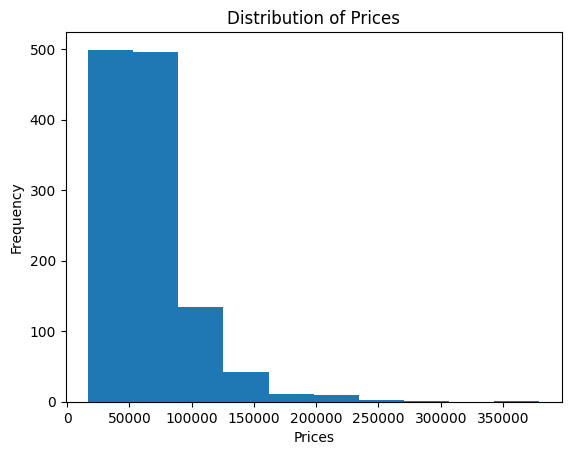

In [36]:
#2.Histogram (Distribution Plot):
import matplotlib.pyplot as plt

plt.hist(df["prices"])
plt.title("Distribution of Prices")
plt.xlabel("Prices")
plt.ylabel("Frequency")
plt.show()

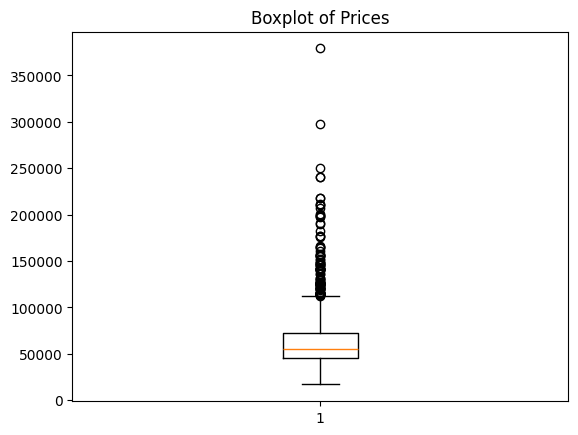

In [217]:
#3.Box Plot (Outliers Detection):
plt.boxplot(df["prices"])
plt.title("Boxplot of Prices")
plt.show()

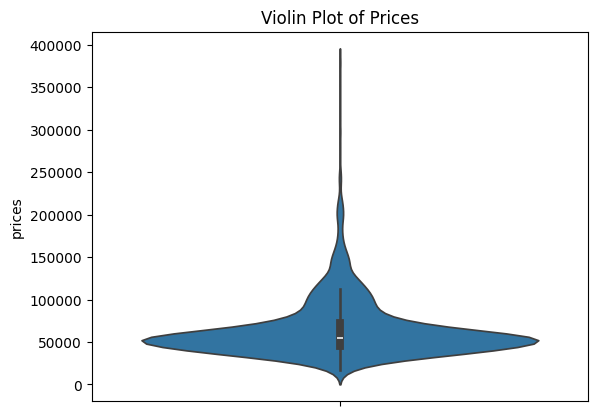

In [218]:
# 4.Violin Plot (Advanced Visualization):

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.violinplot(y=df["prices"])
plt.title("Violin Plot of Prices")
plt.show()

In [219]:
#5.Skewness Check
print("Skewness:", df["prices"].skew())

Skewness: 2.5906981984603092


In [ ]:
##Categorical Variables, calculate the frequency distribution/Count and percentage of the Categorical variable. 
#One can use plots like count plot, bar plot, pie chart.

In [220]:
#Identify Categorical Columns
cat_cols = ["company", "models"]

In [221]:
#Frequency Distribution (Count)
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: company
company
Mercedes-Benz    108
Volkswagen        90
Tesla             86
Porsche           62
Audi              57
                ... 
SEAT               1
SsangYong          1
JAC                1
Elaris             1
Sono               1
Name: count, Length: 73, dtype: int64

Column: models
models
Model         86
Taycan        47
EQE           36
Mustang       30
Enyaq         28
              ..
GranCabrio     1
U6Aiways       1
BEO            1
VISTIQ         1
SionSono       1
Name: count, Length: 239, dtype: int64


In [121]:
#Percentage Distribution:
for col in cat_cols:
    print(f"\nColumn: {col}")
    print((df[col].value_counts(normalize=True) * 100))


Column: company
company
Mercedes-Benz    9.207366
Volkswagen       7.205765
Tesla            7.125701
Porsche          4.963971
Audi             4.883907
                   ...   
e.GO             0.080064
SsangYong        0.080064
JAC              0.080064
Elaris           0.080064
Sono             0.080064
Name: proportion, Length: 74, dtype: float64

Column: models
models
Model         7.125701
Taycan        3.763010
EQE           3.202562
Mustang       2.481986
Enyaq         2.401922
                ...   
GranCabrio    0.080064
U6Aiways      0.080064
BEO           0.080064
VISTIQ        0.080064
SionSono      0.080064
Name: proportion, Length: 245, dtype: float64


In [222]:
#Combined Table (Best for Report)
for col in cat_cols:
    freq = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        "Frequency": freq,
        "Percentage": percent
    })

    print(f"\n{col} Summary:")
    print(result)


company Summary:
               Frequency  Percentage
company                             
Mercedes-Benz        108    9.022556
Volkswagen            90    7.518797
Tesla                 86    7.184628
Porsche               62    5.179616
Audi                  57    4.761905
...                  ...         ...
SEAT                   1    0.083542
SsangYong              1    0.083542
JAC                    1    0.083542
Elaris                 1    0.083542
Sono                   1    0.083542

[73 rows x 2 columns]

models Summary:
            Frequency  Percentage
models                           
Model              86    7.184628
Taycan             47    3.926483
EQE                36    3.007519
Mustang            30    2.506266
Enyaq              28    2.339181
...               ...         ...
GranCabrio          1    0.083542
U6Aiways            1    0.083542
BEO                 1    0.083542
VISTIQ              1    0.083542
SionSono            1    0.083542

[239 rows x 2 colu

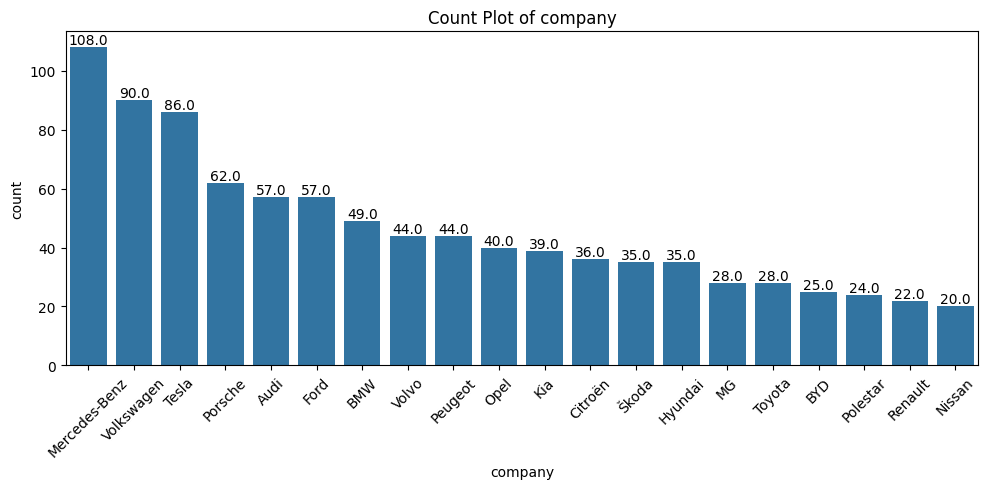

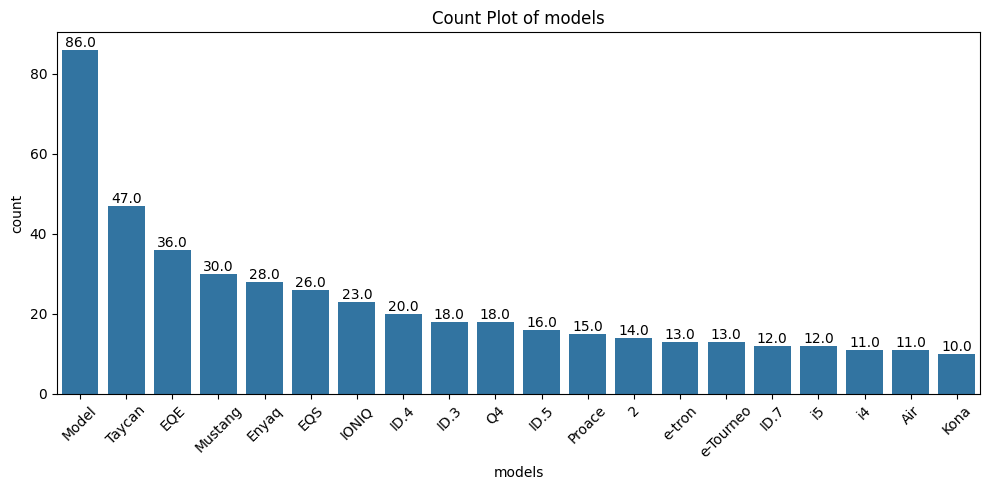

In [224]:
#Count Plot:
for col in cat_cols:
    plt.figure(figsize=(10, 5))

    order = df[col].value_counts().head(20).index
    ax = sns.countplot(x=df[col], order=order)

    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)

    # add labels on bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

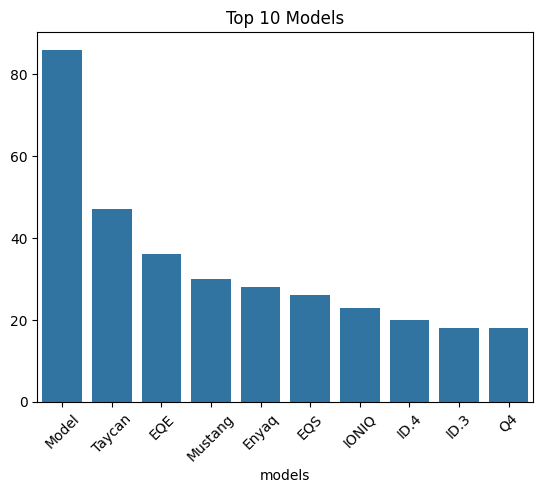

In [225]:
top_models = df["models"].value_counts().head(10)

sns.barplot(x=top_models.index, y=top_models.values)
plt.xticks(rotation=45)
plt.title("Top 10 Models")
plt.show()

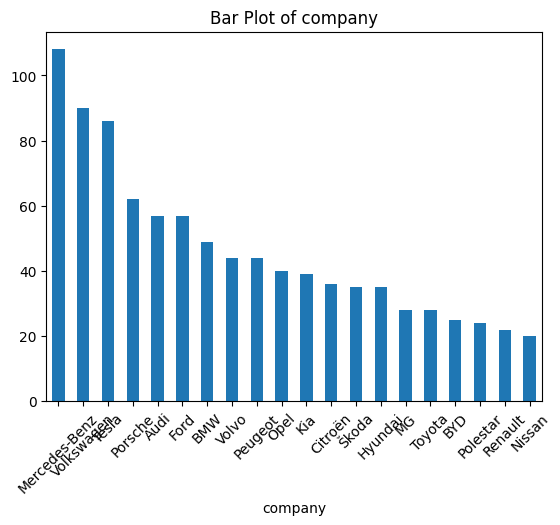

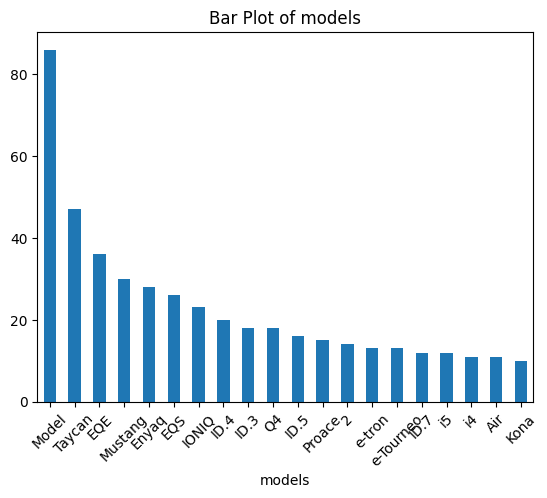

In [226]:
#Bar Plot:
for col in cat_cols:
    df[col].value_counts().head(20).plot(kind='bar')
    plt.xticks(rotation=45)
    plt.title(f"Bar Plot of {col}")
    plt.show()

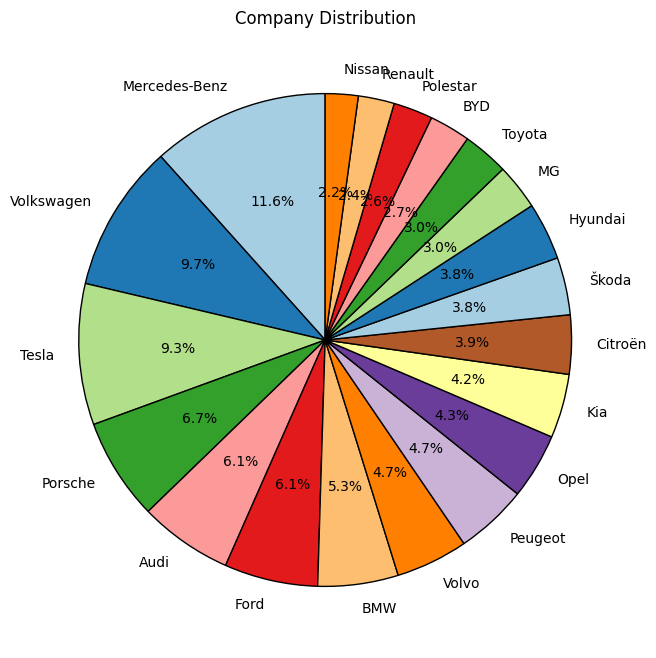

In [227]:
plt.figure(figsize=(8,8))

counts = df["company"].value_counts().head(20)

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors,
    wedgeprops={'edgecolor':'black'}
)

plt.title("Company Distribution")

plt.show()

In [ ]:
#Bivariate / Multivariate Analysis:

In [38]:
#continuous and Categorical Variables:
group_price = df.groupby("company")["prices"].mean()

print(group_price)

company
Abarth     43192.000000
Aiways     41048.000000
Alfa       44000.000000
Alpine     50800.000000
Audi       78195.157895
               ...     
Voyah      55100.000000
XPENG      55766.666667
Zeekr      56078.571429
firefly    55100.000000
Škoda      50348.400000
Name: prices, Length: 73, dtype: float64


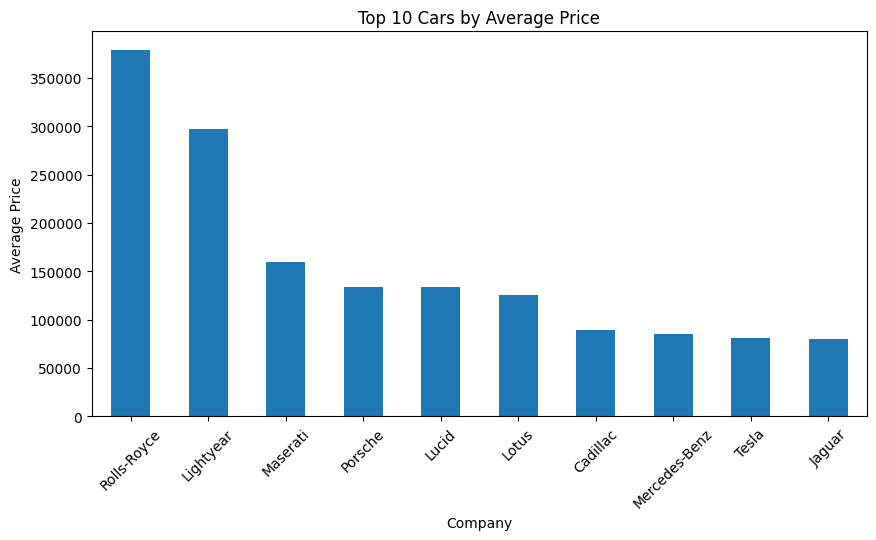

In [39]:
#Visualization:
import matplotlib.pyplot as plt

# Get only top 10 companies based on average price
top_10_cars = group_price.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_10_cars.plot(kind="bar")

plt.title("Top 10 Cars by Average Price")
plt.xlabel("Company")
plt.ylabel("Average Price")

plt.xticks(rotation=45)
plt.show()

In [239]:
pivot_table = pd.pivot_table(
    df,
    values=["prices", "battery"],
    index="company",
    aggfunc="mean"
)

print(pivot_table)

           battery        prices
company                         
Abarth   42.700000  43192.000000
Aiways   60.000000  41048.000000
Alfa     50.800000  44000.000000
Alpine   70.500000  50800.000000
Audi     83.419298  78195.157895
...            ...           ...
Voyah    84.866667  55100.000000
XPENG    80.377778  55766.666667
Zeekr    79.928571  56078.571429
firefly  41.200000  55100.000000
Škoda    70.094286  50348.400000

[73 rows x 2 columns]


In [240]:
#Continuous to Continuous Variables:
#Correlation Matrix:
corr = df[["prices","range","battery","fastcharge","efficiency","weight"]].corr()

print(corr)

              prices     range   battery  fastcharge  efficiency    weight
prices      1.000000  0.515924  0.642170    0.576285    0.243919  0.631486
range       0.515924  1.000000  0.886574    0.701725   -0.223551  0.616512
battery     0.642170  0.886574  1.000000    0.724730    0.226889  0.864343
fastcharge  0.576285  0.701725  0.724730    1.000000    0.044362  0.617255
efficiency  0.243919 -0.223551  0.226889    0.044362    1.000000  0.539204
weight      0.631486  0.616512  0.864343    0.617255    0.539204  1.000000


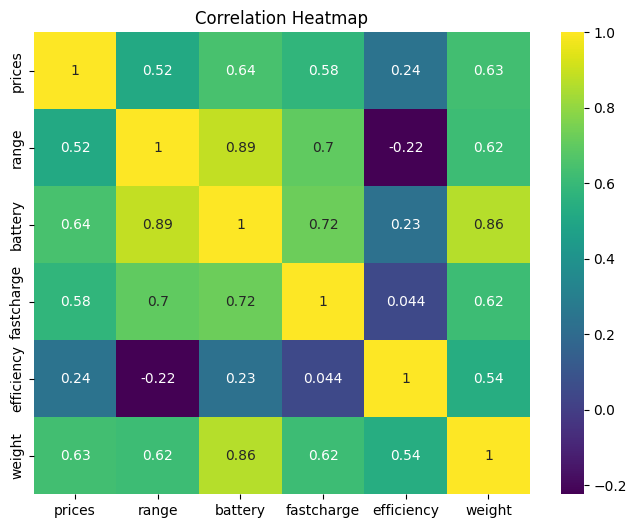

In [243]:
#Heatmap Visualization:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="viridis")

plt.title("Correlation Heatmap")
plt.show()

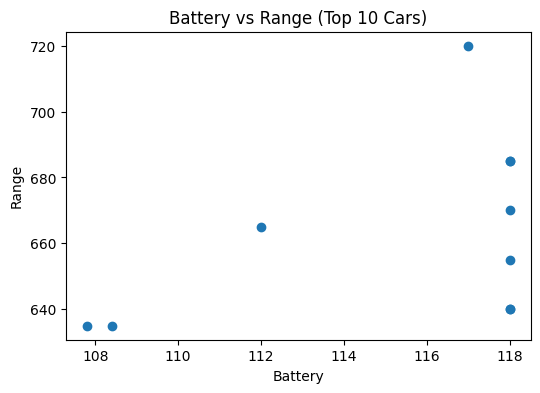

In [40]:
#Scatter Plot Example (Battery vs Range):
# Top 10 cars based on Range

top10_cars = df.sort_values(by="range", ascending=False).head(10)

plt.figure(figsize=(6,4))

plt.scatter(top10_cars["battery"], top10_cars["range"])

plt.title("Battery vs Range (Top 10 Cars)")
plt.xlabel("Battery")
plt.ylabel("Range")

plt.show()

In [42]:
#Categorical to Categorical Variables:
#Cross Tab:
#Company vs Models:
cross_tab = pd.crosstab(df["company"], df["models"])

print(cross_tab)

models   #1  #3  #5  001  02  0Lightyear  2  3  3Seres  4  ...  iX  iX1  iX2  \
company                                                    ...                 
Abarth    0   0   0    0   0           0  0  0       0  0  ...   0    0    0   
Aiways    0   0   0    0   0           0  0  0       0  0  ...   0    0    0   
Alfa      0   0   0    0   0           0  0  0       0  0  ...   0    0    0   
Alpine    0   0   0    0   0           0  0  0       0  0  ...   0    0    0   
Audi      0   0   0    0   0           0  0  0       0  0  ...   0    0    0   
...      ..  ..  ..  ...  ..         ... .. ..     ... ..  ...  ..  ...  ...   
Voyah     0   0   0    0   0           0  0  0       0  0  ...   0    0    0   
XPENG     0   0   0    0   0           0  0  0       0  0  ...   0    0    0   
Zeekr     0   0   0    3   0           0  0  0       0  0  ...   0    0    0   
firefly   0   0   0    0   0           0  0  0       0  0  ...   0    0    0   
Škoda     0   0   0    0   0           0

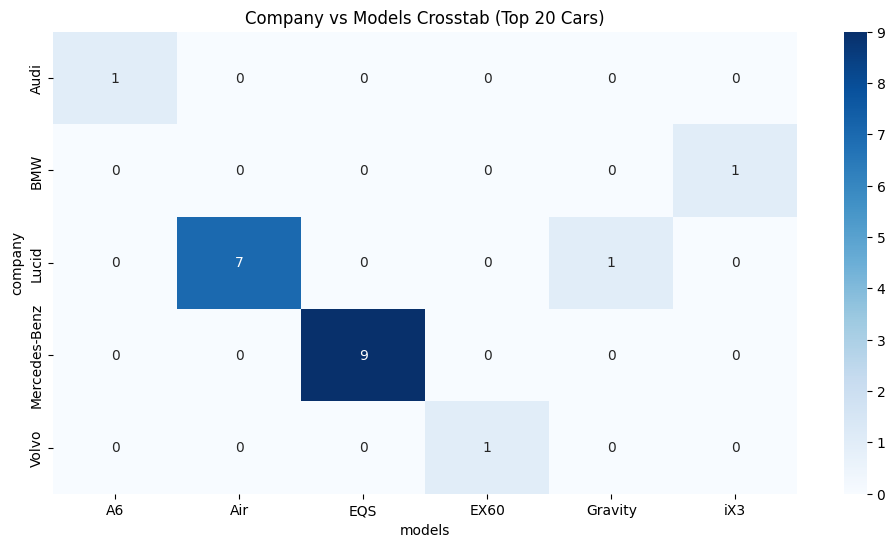

In [45]:
#Visualization:
# If you want Company vs Models Crosstab for Top 10 cars only
# Top 20 cars based on Range
# Top 20 cars based on Range

top20_cars = df.sort_values(by="range", ascending=False).head(20)

# Your correct column name is "models" (not "model")
cross_tab = pd.crosstab(top20_cars["company"], top20_cars["models"])

plt.figure(figsize=(12,6))

sns.heatmap(cross_tab, annot=True, cmap="Blues")

plt.title("Company vs Models Crosstab (Top 20 Cars)")
plt.show()

In [ ]:
#Plots we can be drawn based on the data features/columns: 

#[Box-plot, Bar-plot, count plot, pie chart, scatter-plot, violin-plot,  
#distribution-plot, heat map, histogram and kde-plot etc., Use all plots for  individual variables] 

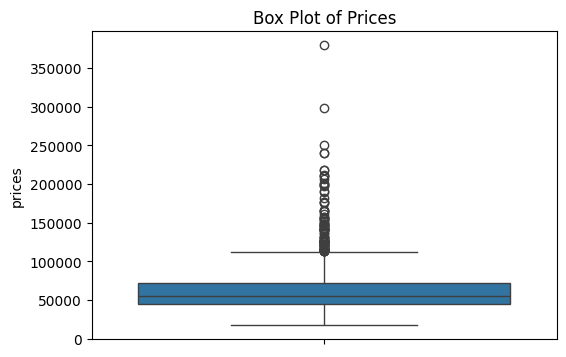

In [255]:
#Box Plot:
#Purpose: Detect outliers and understand spread of data.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=df["prices"])
plt.title("Box Plot of Prices")
plt.show()

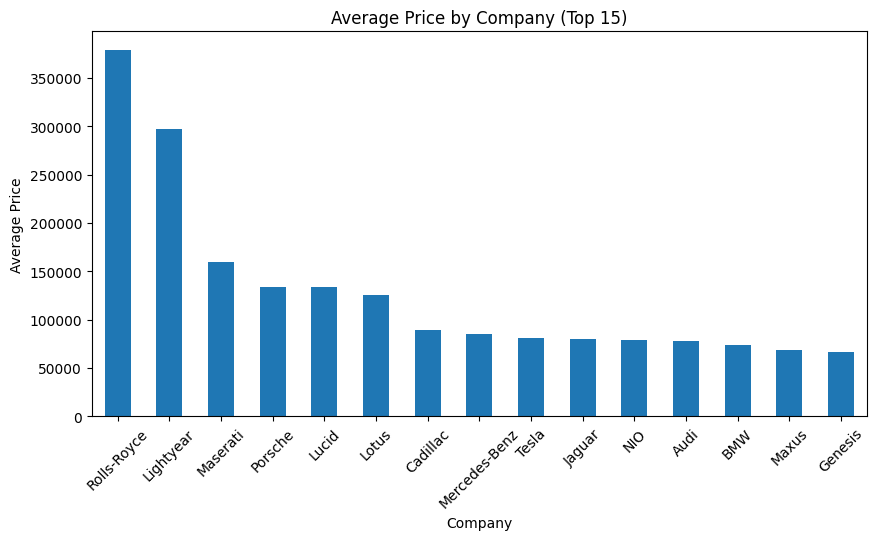

In [46]:
#Bar plot:
#ompare aggregated values across categories
# Top 15 companies based on Average Price

avg_price = df.groupby("company")["prices"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,5))

avg_price.plot(kind="bar")

plt.title("Average Price by Company (Top 15)")
plt.xlabel("Company")
plt.ylabel("Average Price")

plt.xticks(rotation=45)
plt.show()

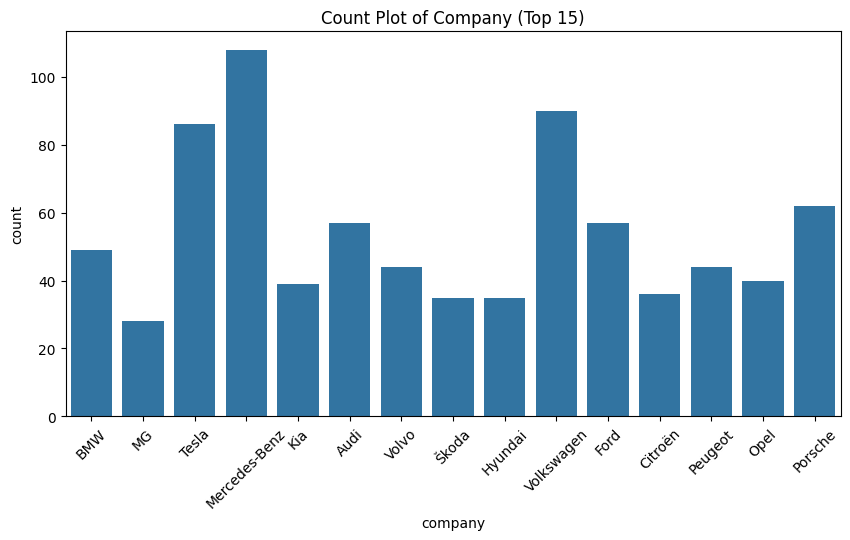

In [47]:
#Count Plot:
#Show frequency count of categorical values:
# Top 15 companies based on count

top15_companies = df["company"].value_counts().head(15).index

top15_data = df[df["company"].isin(top15_companies)]

plt.figure(figsize=(10,5))

sns.countplot(x=top15_data["company"])

plt.title("Count Plot of Company (Top 15)")
plt.xticks(rotation=45)

plt.show()

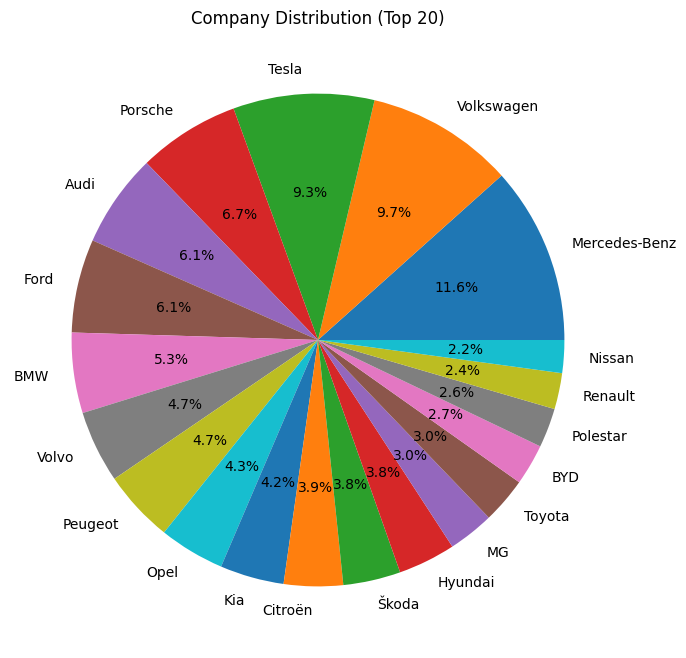

In [48]:
#Pie Chart:
#Show percentage distribution of categories:
# Top 20 companies only

top20_companies = df["company"].value_counts().head(20)

top20_companies.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Company Distribution (Top 20)")
plt.ylabel("")

plt.show()

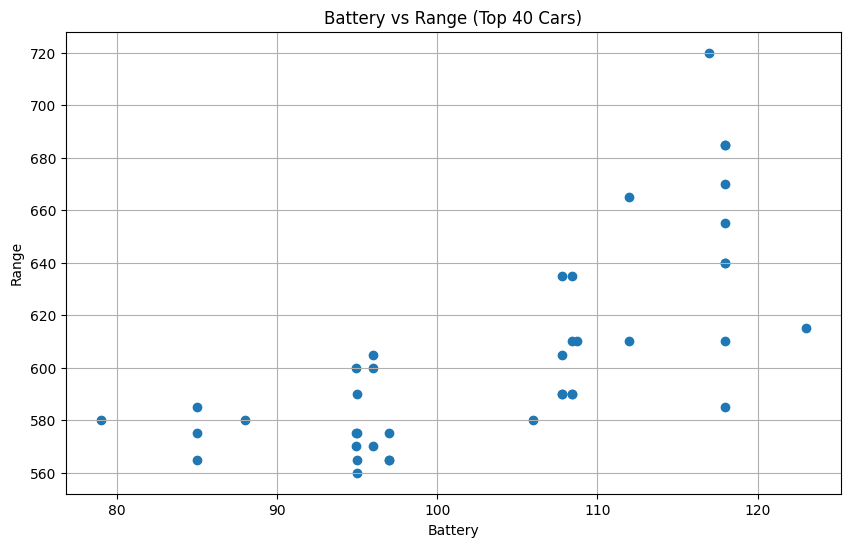

In [49]:
#Scatter Plot:
#Show relationship between two continuous variables:
# Top 40 cars based on Range

top40_cars = df.sort_values(by="range", ascending=False).head(40)

plt.figure(figsize=(10,6))

plt.scatter(
    top40_cars["battery"],
    top40_cars["range"]
)

plt.title("Battery vs Range (Top 40 Cars)")
plt.xlabel("Battery")
plt.ylabel("Range")

plt.grid(True)
plt.show()

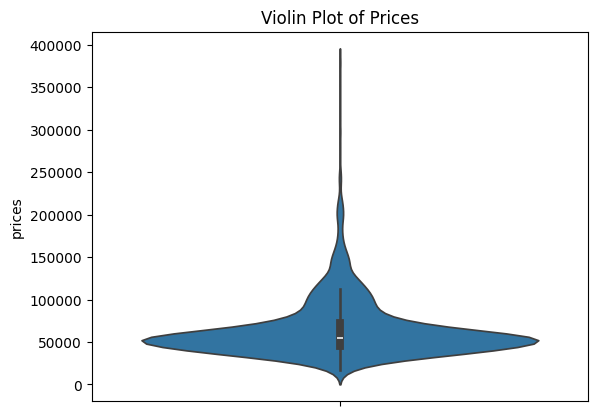

In [265]:
#Violin Plot:
#Show distribution + density:
sns.violinplot(y=df["prices"])

plt.title("Violin Plot of Prices")
plt.show()

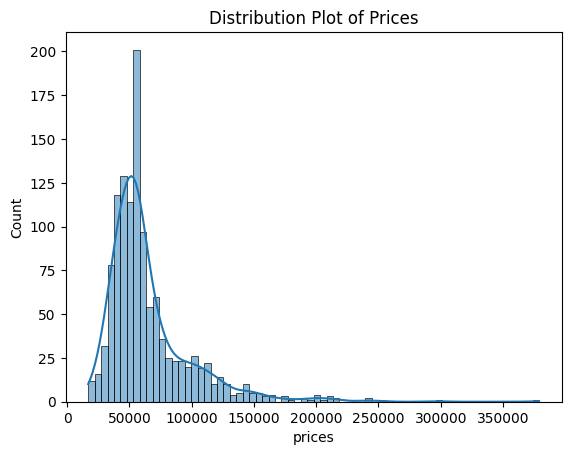

In [266]:
#Distribution Plot:
#Visualize data distribution:
sns.histplot(df["prices"], kde=True)

plt.title("Distribution Plot of Prices")
plt.show()

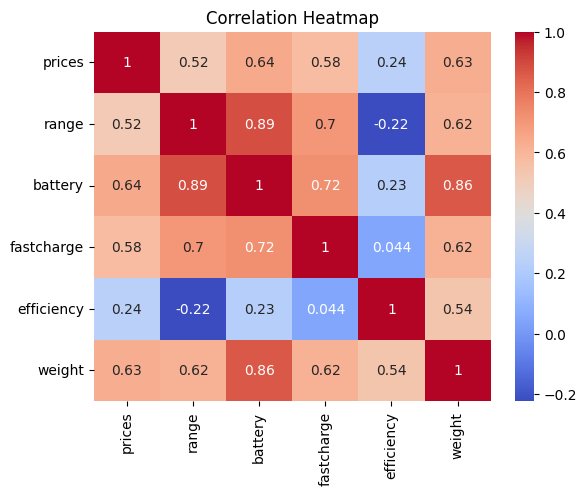

In [267]:
# Heat Map:
#Show correlation between numeric columns:
corr = df[["prices","range","battery","fastcharge","efficiency","weight"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

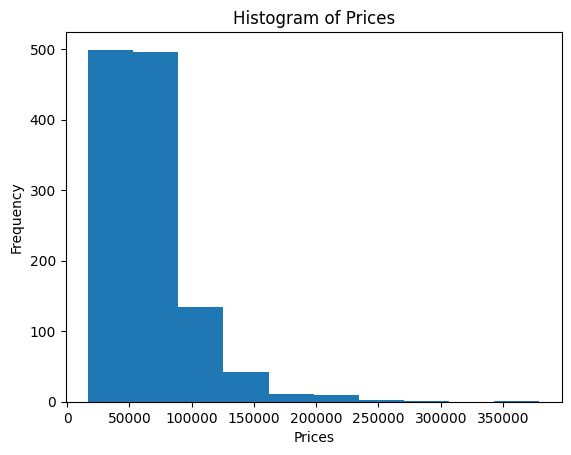

In [268]:
#Histogram:
#Frequency distribution of numeric values:
plt.hist(df["prices"])

plt.title("Histogram of Prices")
plt.xlabel("Prices")
plt.ylabel("Frequency")

plt.show()

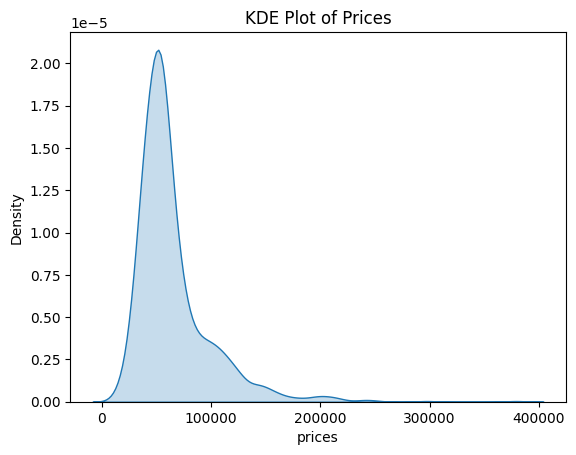

In [258]:
#KDE plot:
#Smooth density curve of data:
sns.kdeplot(df["prices"], fill=True)

plt.title("KDE Plot of Prices")
plt.show()

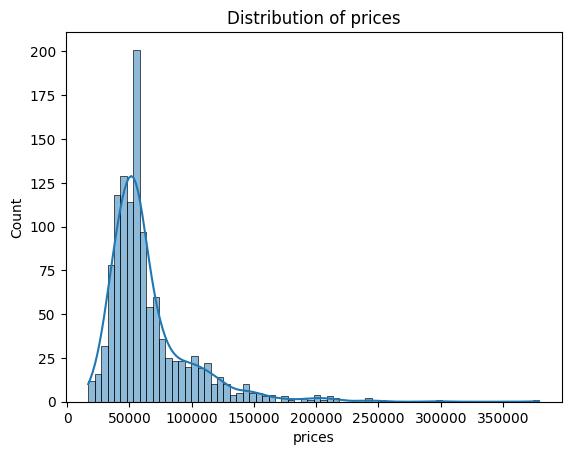

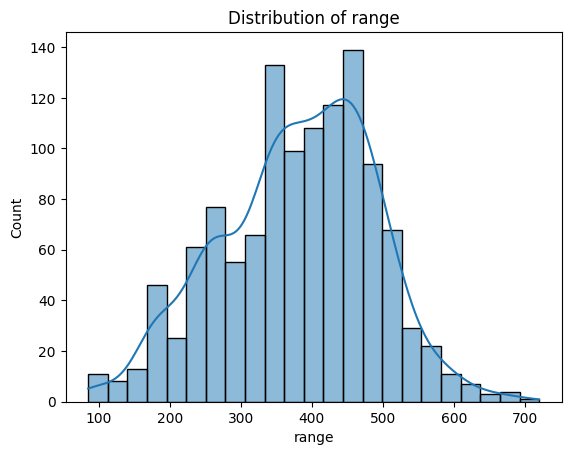

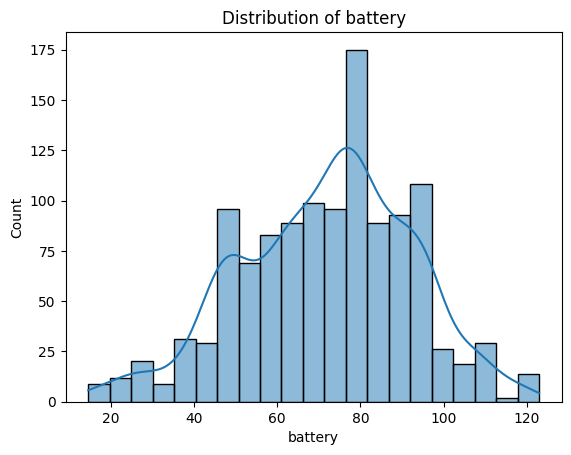

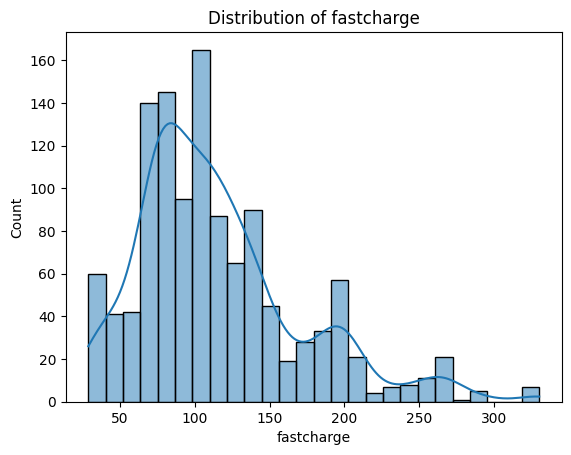

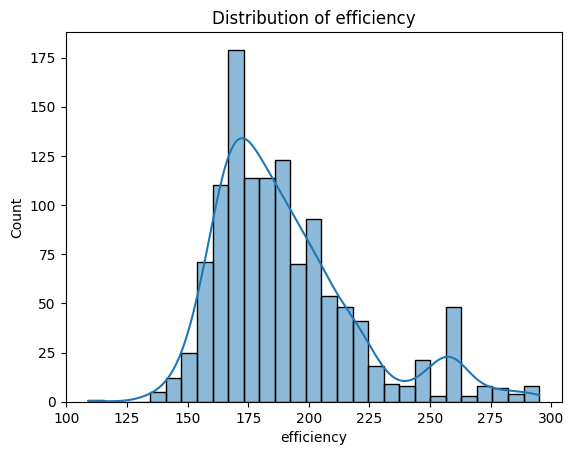

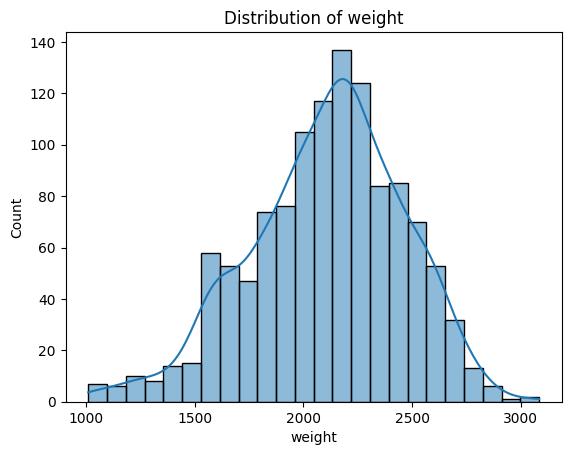

In [259]:
#individual variables:
#continous variables:
num_cols = ["prices","range","battery","fastcharge","efficiency","weight"]

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

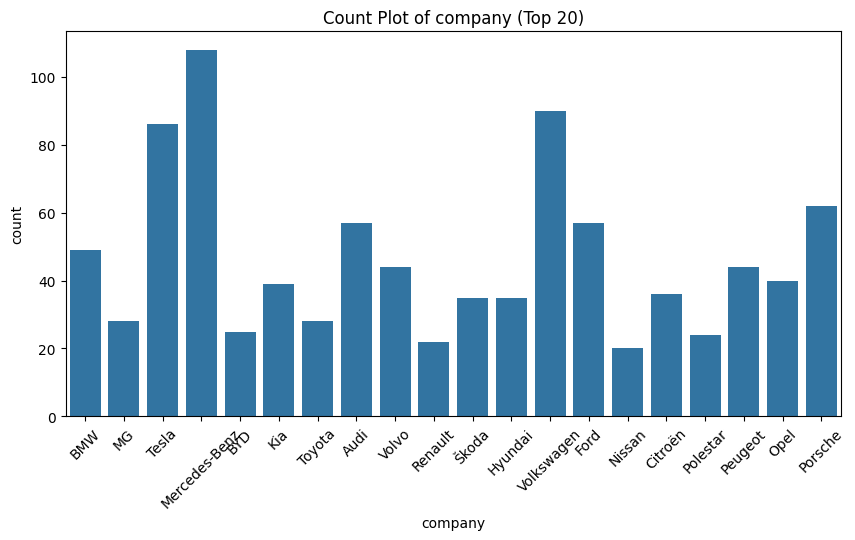

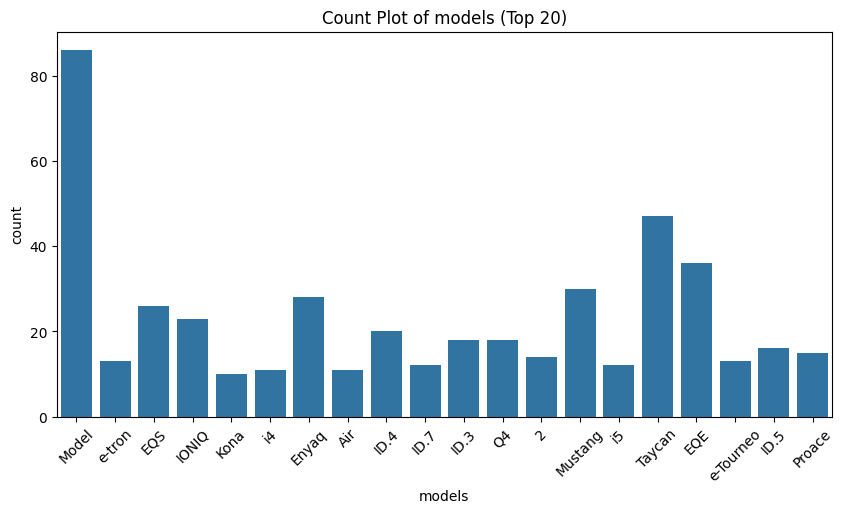

In [50]:
#Categorical variables:
# Top 20 values only for categorical columns

cat_cols = ["company", "models"]

for col in cat_cols:
    top20_values = df[col].value_counts().head(20).index
    filtered_data = df[df[col].isin(top20_values)]

    plt.figure(figsize=(10,5))

    sns.countplot(x=filtered_data[col])

    plt.title(f"Count Plot of {col} (Top 20)")
    plt.xticks(rotation=45)

    plt.show()